## This just tests the non-dimensionalized direct integration of the SDE for x(t)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------


# Physical Constants and Parameters
M1 = 1.0
M2 = 1.0

w1 = 1.0          # Natural frequency of oscillator 1 (rad/s)
w2 = 1.0          # Natural frequency of oscillator 2 (rad/s)

wp1 = 2*(w1+0.0)  # Driving frequency for oscillator 1 (rad/s)
wp2 = 2*(w2+0.0)  # Driving frequency for oscillator 2 (rad/s)

period1 = 2*jnp.pi/w1
period2 = 2*jnp.pi/w2

Fp1 = 0.0        # Amplitude of the wp driving for oscillator 1
Fp2 = 0.00         # Amplitude of the wp driving for oscillator 2

Q1 = 100.0       # Quality factor for oscillator 1
Q2 = 100.0       # Quality factor for oscillator 2

GAMMA1 = w1/(2*Q1)
GAMMA2 = w2/(2*Q2)

gamma1 = 0.00    # Nonlinearity coefficient for oscillator 1 (Duffing term)
gamma2 = 0.00    # Nonlinearity coefficient for oscillator 2 (Duffing term)

c = .01


k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .3             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 1000# Start time
period = 2*jnp.pi/w1
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, 1000)


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(Q1, P1, Q2, P2, args):
    dw = wp1/2 - w1  # detuning term
    
    # Parameters of the Hidden oscillator
    gamma_h, wp_h, Fp_h = args
    
    # Single oscillator terms (for both oscillators)
    H1 = 3*gamma1/(16*wp1) * (Q1**2 + P1**2)**2 + dw/2 *(Q1**2 - P1**2) + Fp1/(4*M1*wp1) * (P1**2 - Q1**2)
    H2 = 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)

    # Coupling term
    H_coupling = c/4 * ((Q1 - Q2)**2 + (P1 - P2)**2)
    
    return H1 + H2 + H_coupling


def drift_QP_fn(t, state, args):
    """
    Drift function for the RWA equations
    """
    Q1, P1, Q2, P2 = state  # Unpack all state variables
    
    # Calculate gradients of Hamiltonian for both oscillators
    dQ1dt =  jax.grad(Hamiltonian, 1)(Q1, P1, Q2, P2, args) - GAMMA1*Q1
    dP1dt = -jax.grad(Hamiltonian, 0)(Q1, P1, Q2, P2, args) - GAMMA1*P1
    dQ2dt =  jax.grad(Hamiltonian, 3)(Q1, P1, Q2, P2, args) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian, 2)(Q1, P1, Q2, P2, args) - GAMMA2*P2
    
    return jnp.array([dQ1dt, dP1dt, dQ2dt, dP2dt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations for two coupled oscillators.
    Returns a 4x4 matrix with noise terms for both oscillators.
    """
    # Noise strength for oscillator 1
    noise_strength_QP1 = jnp.sqrt(2*GAMMA1*k_B * T/(M1*w1**2))
    # Noise strength for oscillator 2  
    noise_strength_QP2 = jnp.sqrt(2*GAMMA2*k_B * T/(M2*w2**2))
    
    # Create 4x4 matrix for both oscillators [Q1, P1, Q2, P2]
    noise_matrix = jnp.zeros((4, 4))
    noise_matrix = noise_matrix.at[0:2, 0:2].set(noise_strength_QP1 * jnp.eye(2))  # First oscillator
    noise_matrix = noise_matrix.at[2:4, 2:4].set(noise_strength_QP2 * jnp.eye(2))  # Second oscillator
    return noise_matrix



In [4]:
w_shape = (4,)  # state is (Q, P)
brownian_motion_QP = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)
terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion_QP))
saveat = diffrax.SaveAt(ts=ts_dim)

y0_QP = jnp.array([0, 0, 0, 0])

@jax.jit
def solve_SDE_QP(args):
    """
    Solve the SDE for the QP equations
    """
    solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=args,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000000,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
    )
    
    sde_samples_QP = solution_QP.ys
    return sde_samples_QP

In [5]:
args_0 = (0.0, wp2, 0.0)
args_target = (0.03, wp2, 0.1)
sde_samples_QP_0 = solve_SDE_QP(args_0)
sde_samples_QP_target = solve_SDE_QP(args_target)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
100.00%|██████████| [00:01<00:00, 81.91%/s]
100.00%|██████████| [00:02<00:00, 42.74%/s]


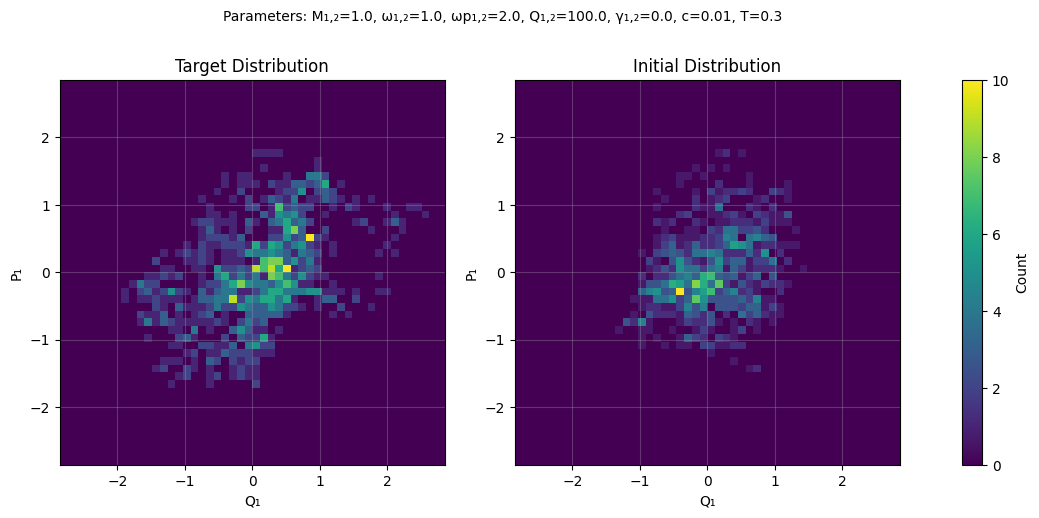

In [6]:

# Calculate decoherence time and use it for sampling
decoherence_time = 2 * Q1 / w1  # Using parameters of first oscillator
dt = ts_dim[1] - ts_dim[0]
sample_step = int(decoherence_time / dt)  # Use this for thinning the data
sample_step = 1
# Create figure with proper spacing for colorbar
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.2)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])  # Separate axis for colorbar

# Get global min/max for consistent axes
all_Q = jnp.concatenate([sde_samples_QP_target[:, 0], sde_samples_QP_0[:, 0]])
all_P = jnp.concatenate([sde_samples_QP_target[:, 1], sde_samples_QP_0[:, 1]])
q_lim = max(abs(all_Q.min()), abs(all_Q.max()))
p_lim = max(abs(all_P.min()), abs(all_P.max()))
lim = max(q_lim, p_lim) * 1.1  # Add 10% margin

# Plot distributions with same colormap and scale
bins = 50
range_lim = [[-lim, lim], [-lim, lim]]
hist1 = ax1.hist2d(sde_samples_QP_target[::sample_step, 0], 
                   sde_samples_QP_target[::sample_step, 1], 
                   bins=bins, cmap='viridis', range=range_lim)
hist2 = ax2.hist2d(sde_samples_QP_0[::sample_step, 0], 
                   sde_samples_QP_0[::sample_step, 1], 
                   bins=bins, cmap='viridis', range=range_lim)

# Set identical axes properties
for ax in [ax1, ax2]:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Q₁')
    ax.set_ylabel('P₁')

# Titles
ax1.set_title('Target Distribution')
ax2.set_title('Initial Distribution')

# Add colorbar in its own axis
plt.colorbar(hist1[3], cax=cax, label='Count')

# Compact parameter title
title = (f'Parameters: M₁,₂={M1}, ω₁,₂={w1}, ωp₁,₂={wp1}, '
         f'Q₁,₂={Q1}, γ₁,₂={gamma1}, c={c}, T={T}')
plt.suptitle(title, y=1.02, size=10)

plt.show()

In [21]:
def Hamiltonian_clamped(Q2, P2, Q1_fixed, P1_fixed, args):
    dw = wp1/2 - w1
    gamma_h, wp_h, Fp_h = args
    
    H2 = 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)
    H_coupling = c/4 * ((Q1_fixed - Q2)**2 + (P1_fixed - P2)**2)
    
    return H2 + H_coupling

def drift_QP_clamped(t, state, Q1_fixed, P1_fixed, args):
    Q2, P2 = state  # Now state only contains Q2 and P2
    
    dQ2dt = jax.grad(Hamiltonian_clamped, 1)(Q2, P2, Q1_fixed, P1_fixed, args) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian_clamped, 0)(Q2, P2, Q1_fixed, P1_fixed, args) - GAMMA2*P2
    
    return jnp.array([dQ2dt, dP2dt])

@jax.jit
def solve_SDE_QP_clamped(Q1_fixed, P1_fixed, args):
    """
    Solve the SDE for the QP equations with clamped Q1 and P1 values
    """
    # Define new terms for clamped system (2D instead of 4D)
    w_shape_clamped = (2,)  # state is now just (Q2, P2)
    brownian_motion_QP_clamped = diffrax.VirtualBrownianTree(
        t0, t1, 1.e-11, w_shape_clamped, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
    )
    
    # Create partial function with fixed Q1, P1
    drift_fn = lambda t, state, args: drift_QP_clamped(t, state, Q1_fixed, P1_fixed, args)
    
    terms_QP_clamped = MultiTerm(
        ODETerm(drift_fn), 
        ControlTerm(lambda t, state, args: diffusion_QP_fn(t, state, args)[2:4, 2:4], brownian_motion_QP_clamped)
    )
    
    y0_QP_clamped = jnp.array([0, 0])  # Initial conditions for Q2, P2 only
    
    solution_QP = diffrax.diffeqsolve(
        terms_QP_clamped,
        solver=diffrax.SRA1(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0_QP_clamped,
        args=args,
        saveat=saveat,
        progress_meter=diffrax.TqdmProgressMeter(),
        max_steps=10000000000,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
    )
    
    sde_samples_QP = solution_QP.ys
    return sde_samples_QP

In [22]:
downsample_step = 100

# Downsample the Q1,P1 values from the zero simulation
Q1_samples = sde_samples_QP_0[::downsample_step, 0]
P1_samples = sde_samples_QP_0[::downsample_step, 1]


Q1_samples

Array([ 0.        ,  0.94381663,  0.78418973,  0.08852041, -0.07064349,
        0.17837311,  0.97841313,  0.78896768,  0.0779449 ,  0.068209  ],      dtype=float64)

In [23]:
P1_samples

Array([ 0.        , -0.76818042, -0.45866122,  1.21039671,  0.33441879,
        0.19196476,  0.1152833 ,  0.47745812, -0.0358345 , -0.33415057],      dtype=float64)

In [24]:
Q1P1_pairs

Array([[ 0.        ,  0.        ],
       [ 0.94381663, -0.76818042],
       [ 0.78418973, -0.45866122],
       [ 0.08852041,  1.21039671],
       [-0.07064349,  0.33441879],
       [ 0.17837311,  0.19196476],
       [ 0.97841313,  0.1152833 ],
       [ 0.78896768,  0.47745812],
       [ 0.0779449 , -0.0358345 ],
       [ 0.068209  , -0.33415057]], dtype=float64)

In [25]:
# Calculate appropriate downsampling step
# decoherence_time = 2 * Q1 / w1
# dt = ts_dim[1] - ts_dim[0]


# Create pairs of Q1,P1 values
Q1P1_pairs = jnp.stack([Q1_samples, P1_samples], axis=1)  # Shape: (n_samples, 2)

# Vectorize the clamped solver over Q1,P1 pairs

def batch_solve_clamped(Q1P1_pair):
    return solve_SDE_QP_clamped(Q1P1_pair[0], Q1P1_pair[1], args_0)


# Run the parallel simulation
clamped_samples = jax.vmap(batch_solve_clamped)(Q1P1_pairs)

100.00%|██████████| [00:06<00:00, 16.34%/s]


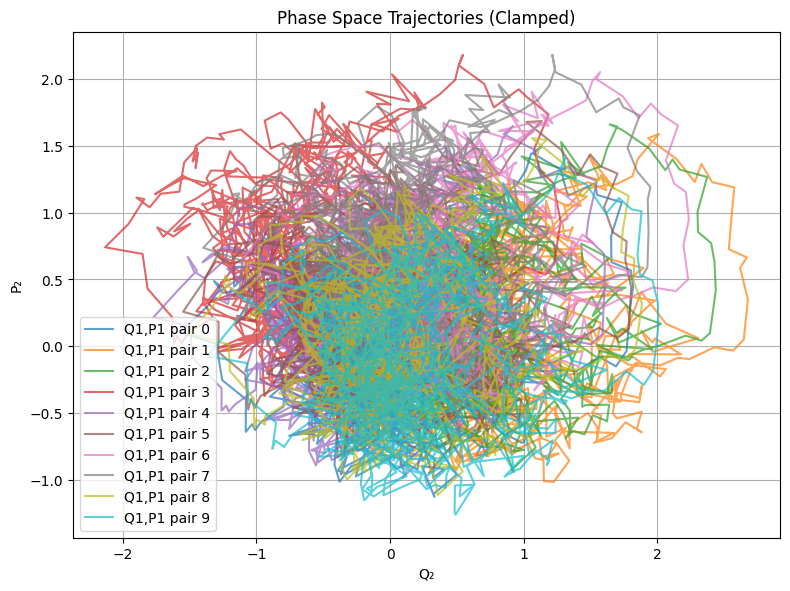

In [26]:
# Create a single square figure
fig, ax = plt.subplots(figsize=(8, 8))

# Number of trajectories to plot
n_trajectories = min(10, clamped_samples.shape[0])

# Plot phase space trajectories
for i in range(n_trajectories):
    ax.plot(clamped_samples[i, :, 0], clamped_samples[i, :, 1], 
            label=f'Q1,P1 pair {i}', alpha=0.7)
    
ax.set_xlabel('Q₂')
ax.set_ylabel('P₂')
ax.set_title('Phase Space Trajectories (Clamped)')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [27]:
def dH_dgamma_h(Q1, P1, Q2, P2, args):
    """Partial derivative of Hamiltonian with respect to gamma_h"""
    gamma_h, wp_h, Fp_h = args
    
    # Only H2 term depends on gamma_h
    # From: 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2
    return 3/(16*wp_h) * (Q2**2 + P2**2)**2

def dH_dFp_h(Q1, P1, Q2, P2, args):
    """Partial derivative of Hamiltonian with respect to Fp_h"""
    gamma_h, wp_h, Fp_h = args
    
    # Only H2 term depends on Fp_h
    # From: Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)
    return 1/(4*M2*wp_h) * (P2**2 - Q2**2)

In [28]:
def compute_gradients(sde_samples_free, sde_samples_clamped, args):
    """
    Compute gradients using Boltzmann machine training approach.
    
    Args:
        sde_samples_free: samples from free running simulation (Q1,P1,Q2,P2)
        sde_samples_clamped: samples from clamped simulation (Q2,P2)
        args: (gamma_h, wp_h, Fp_h)
    
    Returns:
        gradients for gamma_h and Fp_h
    """
    # Compute average gradient for free running case
    dH_dgamma_free = jnp.mean(jax.vmap(
        lambda sample: dH_dgamma_h(sample[0], sample[1], sample[2], sample[3], args)
    )(sde_samples_free))
    
    dH_dFp_free = jnp.mean(jax.vmap(
        lambda sample: dH_dFp_h(sample[0], sample[1], sample[2], sample[3], args)
    )(sde_samples_free))
    
    # Compute average gradient for clamped case
    # Note: for clamped case, we need to use the fixed Q1,P1 values
    Q1_fixed = sde_samples_free[0,0]  # using first sample's Q1
    P1_fixed = sde_samples_free[0,1]  # using first sample's P1
    
    dH_dgamma_clamped = jnp.mean(jax.vmap(
        lambda sample: dH_dgamma_h(Q1_fixed, P1_fixed, sample[0], sample[1], args)
    )(sde_samples_clamped))
    
    dH_dFp_clamped = jnp.mean(jax.vmap(
        lambda sample: dH_dFp_h(Q1_fixed, P1_fixed, sample[0], sample[1], args)
    )(sde_samples_clamped))
    
    # Compute gradient as difference between free and clamped averages
    grad_gamma = dH_dgamma_free - dH_dgamma_clamped
    grad_Fp = dH_dFp_free - dH_dFp_clamped
    
    return grad_gamma, grad_Fp

# Training loop
def train_step(args, learning_rate=0.01):
    """
    Perform one training step
    """
    # Get samples from current parameters
    sde_samples_free = solve_SDE_QP(args)
    
    # Get clamped samples (using the first Q1,P1 pair for simplicity)
    Q1_fixed, P1_fixed = sde_samples_free[0,0], sde_samples_free[0,1]
    sde_samples_clamped = solve_SDE_QP_clamped(Q1_fixed, P1_fixed, args)
    
    # Compute gradients
    grad_gamma, grad_Fp = compute_gradients(sde_samples_free, sde_samples_clamped, args)
    
    # Update parameters
    gamma_h, wp_h, Fp_h = args
    new_gamma_h = gamma_h - learning_rate * grad_gamma
    new_Fp_h = Fp_h - learning_rate * grad_Fp
    
    return (new_gamma_h, wp_h, new_Fp_h)

# Run training for multiple steps
def train(initial_args, n_steps=100, learning_rate=0.01):
    args = initial_args
    for step in range(n_steps):
        args = train_step(args, learning_rate)
        if step % 10 == 0:
            print(f"Step {step}: gamma_h = {args[0]:.4f}, Fp_h = {args[2]:.4f}")
    return args

In [29]:
# Starting from args_0 and training towards args_target
initial_args = args_0  # (gamma2, wp2, Fp2)
final_args = train(initial_args, n_steps=100, learning_rate=0.01)

100.00%|██████████| [00:01<00:00, 82.16%/s]
100.00%|██████████| [00:01<00:00, 88.95%/s]


Step 0: gamma_h = -0.0001, Fp_h = 0.0001


100.00%|██████████| [00:01<00:00, 83.39%/s]
100.00%|██████████| [00:01<00:00, 88.31%/s]
100.00%|██████████| [00:01<00:00, 84.02%/s]
100.00%|██████████| [00:01<00:00, 87.73%/s]
100.00%|██████████| [00:01<00:00, 81.19%/s]
100.00%|██████████| [00:01<00:00, 83.99%/s]
100.00%|██████████| [00:01<00:00, 81.81%/s]
100.00%|██████████| [00:01<00:00, 89.55%/s]
100.00%|██████████| [00:01<00:00, 83.49%/s]
100.00%|██████████| [00:01<00:00, 89.96%/s]
100.00%|██████████| [00:01<00:00, 84.79%/s]
100.00%|██████████| [00:01<00:00, 88.53%/s]
100.00%|██████████| [00:01<00:00, 82.73%/s]
100.00%|██████████| [00:01<00:00, 87.92%/s]
100.00%|██████████| [00:01<00:00, 83.02%/s]
100.00%|██████████| [00:01<00:00, 89.64%/s]
100.00%|██████████| [00:01<00:00, 82.29%/s]
100.00%|██████████| [00:01<00:00, 91.79%/s]
100.00%|██████████| [00:01<00:00, 84.15%/s]
100.00%|██████████| [00:01<00:00, 90.98%/s]


Step 10: gamma_h = -0.0010, Fp_h = 0.0011


100.00%|██████████| [00:01<00:00, 84.26%/s]
100.00%|██████████| [00:01<00:00, 91.57%/s]
100.00%|██████████| [00:01<00:00, 84.95%/s]
100.00%|██████████| [00:01<00:00, 91.20%/s]
100.00%|██████████| [00:01<00:00, 82.39%/s]
100.00%|██████████| [00:01<00:00, 91.09%/s]
100.00%|██████████| [00:01<00:00, 83.33%/s]
100.00%|██████████| [00:01<00:00, 88.80%/s]
100.00%|██████████| [00:01<00:00, 82.45%/s]
100.00%|██████████| [00:01<00:00, 92.99%/s]
100.00%|██████████| [00:01<00:00, 85.68%/s]
100.00%|██████████| [00:01<00:00, 91.82%/s]
100.00%|██████████| [00:01<00:00, 81.96%/s]
100.00%|██████████| [00:01<00:00, 91.92%/s]
100.00%|██████████| [00:01<00:00, 83.84%/s]
100.00%|██████████| [00:01<00:00, 90.65%/s]
100.00%|██████████| [00:01<00:00, 83.02%/s]
100.00%|██████████| [00:01<00:00, 91.53%/s]
100.00%|██████████| [00:01<00:00, 80.75%/s]
100.00%|██████████| [00:01<00:00, 90.51%/s]


...

100.00%|██████████| [00:01<00:00, 82.07%/s]
100.00%|██████████| [00:01<00:00, 90.96%/s]
100.00%|██████████| [00:01<00:00, 80.80%/s]
100.00%|██████████| [00:01<00:00, 89.29%/s]
100.00%|██████████| [00:01<00:00, 81.29%/s]
100.00%|██████████| [00:01<00:00, 91.56%/s]
100.00%|██████████| [00:01<00:00, 80.61%/s]
100.00%|██████████| [00:01<00:00, 92.63%/s]
100.00%|██████████| [00:01<00:00, 80.46%/s]
100.00%|██████████| [00:01<00:00, 90.74%/s]
100.00%|██████████| [00:01<00:00, 80.30%/s]
100.00%|██████████| [00:01<00:00, 88.84%/s]
100.00%|██████████| [00:01<00:00, 78.61%/s]
100.00%|██████████| [00:01<00:00, 90.63%/s]
100.00%|██████████| [00:01<00:00, 80.08%/s]
100.00%|██████████| [00:01<00:00, 89.42%/s]
100.00%|██████████| [00:01<00:00, 78.96%/s]
100.00%|██████████| [00:01<00:00, 90.17%/s]
100.00%|██████████| [00:01<00:00, 79.15%/s]
100.00%|██████████| [00:01<00:00, 91.00%/s]


Step 80: gamma_h = -0.0129, Fp_h = 0.0067


100.00%|██████████| [00:01<00:00, 74.11%/s]
100.00%|██████████| [00:01<00:00, 84.15%/s]
100.00%|██████████| [00:01<00:00, 77.32%/s]
100.00%|██████████| [00:01<00:00, 85.89%/s]
100.00%|██████████| [00:01<00:00, 75.51%/s]
100.00%|██████████| [00:01<00:00, 89.34%/s]
100.00%|██████████| [00:01<00:00, 75.77%/s]
100.00%|██████████| [00:01<00:00, 89.10%/s]
100.00%|██████████| [00:01<00:00, 76.34%/s]
100.00%|██████████| [00:01<00:00, 90.79%/s]
100.00%|██████████| [00:01<00:00, 77.98%/s]
100.00%|██████████| [00:01<00:00, 90.67%/s]
100.00%|██████████| [00:01<00:00, 75.97%/s]
100.00%|██████████| [00:01<00:00, 87.66%/s]
100.00%|██████████| [00:01<00:00, 75.06%/s]
100.00%|██████████| [00:01<00:00, 87.82%/s]
100.00%|██████████| [00:01<00:00, 73.69%/s]
100.00%|██████████| [00:01<00:00, 87.46%/s]
100.00%|██████████| [00:01<00:00, 72.38%/s]
100.00%|██████████| [00:01<00:00, 84.51%/s]


Step 90: gamma_h = -0.0150, Fp_h = 0.0069


100.00%|██████████| [00:01<00:00, 69.78%/s]
100.00%|██████████| [00:01<00:00, 83.14%/s]
100.00%|██████████| [00:01<00:00, 71.29%/s]
100.00%|██████████| [00:01<00:00, 87.48%/s]
100.00%|██████████| [00:01<00:00, 74.90%/s]
100.00%|██████████| [00:01<00:00, 87.72%/s]
100.00%|██████████| [00:01<00:00, 73.75%/s]
100.00%|██████████| [00:01<00:00, 87.03%/s]
100.00%|██████████| [00:01<00:00, 74.11%/s]
100.00%|██████████| [00:01<00:00, 85.16%/s]
100.00%|██████████| [00:01<00:00, 70.08%/s]
100.00%|██████████| [00:01<00:00, 84.94%/s]
100.00%|██████████| [00:01<00:00, 74.08%/s]
100.00%|██████████| [00:01<00:00, 87.40%/s]
100.00%|██████████| [00:01<00:00, 74.84%/s]
100.00%|██████████| [00:01<00:00, 86.90%/s]
100.00%|██████████| [00:01<00:00, 72.73%/s]
100.00%|██████████| [00:01<00:00, 84.63%/s]
